# Plot comparison of admission numbers with various coefficients

Compared observed admissions numbers with values predicted using SSNAP coefficients and derived deprivation-level coefficients.


__Inputs:__

+ MSOA-level admissions and population data for calculating admissions from resulting coefficients.
+ SSNAP-derived coefficients and England-level admissions by age band.
+ Best fit and minimum/maximum coefficients from the optimisation.

__Results:__

The "best" coefficients give a better r-squared than the starting SSNAP coefficients. On the scatter plot, this appears to be due to removing the effect of admissions in the most deprived areas being underpredicted and the least deprived areas being overpredicted.

Using the minimum and maximum coefficients makes a difference of around +/-10% to the admissions numbers calculated with the "best" coefficients.

__Method:__

Calculate the MSOA-level admissions numbers for each set of coefficients.

Compare the total admission numbers for the minimum/maximum coefficient ranges to gauge the uncertainty in the "best" coefficients.




## Code setup

In [114]:
import os
import polars as pl
from scipy.optimize import minimize, basinhopping
import numpy as np
import matplotlib.pyplot as plt

## Load data

Coefficients:

In [115]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

In [116]:
df_pop_admissions

Age Groups,population,prop_of_all_pop,count,prop_of_all_admissions,admissions_annual,admissions_annual_boost,prob_stroke_given_age
str,i64,f64,i64,f64,f64,f64,f64
"""Under 65""",45933245,0.816055,38827,0.231449,12942.33333,18737.66819,0.000408
"""65-69""",2796740,0.049687,15324,0.091347,5108.0,7395.26689,0.002644
"""70-74""",2779326,0.049378,21508,0.12821,7169.33333,10379.62674,0.003735
"""75-79""",1940686,0.034478,24150,0.143959,8050.0,11654.63948,0.006005
"""80 and over""",2836964,0.050402,67947,0.405035,22649.0,32790.7987,0.011558


Pick out SSNAP coefficients:

In [117]:
coeffs_ssnap = df_pop_admissions['prob_stroke_given_age'].to_numpy()

coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

Pick out admissions numbers:

In [118]:
dict_admissions_age = dict(zip(df_pop_admissions['Age Groups'], df_pop_admissions['admissions_annual_boost']))

admissions_by_age = list(dict_admissions_age.values())

dict_admissions_age

{'Under 65': 18737.66819,
 '65-69': 7395.26689,
 '70-74': 10379.62674,
 '75-79': 11654.63948,
 '80 and over': 32790.7987}

Fitted coefficients:

In [119]:
df_best_nudged = pl.read_csv(os.path.join('outputs', 'nudge_walk_best.csv'))

Pick out best set of coefficients:

In [120]:
df_best_coeffs = df_best_nudged.filter(df_best_nudged['fitness'] == df_best_nudged['fitness'].min())[0]

In [121]:
df_best_coeffs

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_err_rats,wrong_rat,fitness,wrong_rat_under65,wrong_rat_65,wrong_rat_70,wrong_rat_75,wrong_rat_over80,sum_err_rats_q00,sum_err_rats_q02,sum_err_rats_q04,sum_err_rats_q06,sum_err_rats_q08,dir
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
0.0006,0.005,0.005,0.007,0.012,0.0005,0.003,0.004,0.007,0.012,0.0003,0.002,0.004,0.006,0.012,0.0003,0.002,0.003,0.005,0.012,0.0003,0.002,0.003,0.005,0.01,1512.89574,1.0241,1549.36044,0.99141,1.00004,0.99002,0.99959,0.99491,334.23527,325.72921,286.36712,272.2158,294.34834,"""randomseed06"""


Get into right format:

In [122]:
coeff_names = df_best_coeffs.columns[:25]

coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

In [123]:
coeffs = df_best_coeffs[coeff_names].to_numpy().reshape(5, 5)

In [124]:
coeffs[:, 0]

array([0.0006, 0.0005, 0.0003, 0.0003, 0.0003])

In [125]:
qmin_list = np.arange(0.0, 1.0, 0.2)

In [126]:
coeffs_depriv_all = pl.DataFrame()
coeffs_depriv_all = coeffs_depriv_all.with_columns(pl.Series('depriv_quantile_min', qmin_list))
for a, age_band in enumerate(['age_less65', 'age_65', 'age_70', 'age_75', 'age_over80']):
    coeffs_depriv_all = coeffs_depriv_all.with_columns(pl.Series(age_band, coeffs[:, a]))                                                   

In [127]:
coeffs_depriv_all

depriv_quantile_min,age_less65,age_65,age_70,age_75,age_over80
f64,f64,f64,f64,f64,f64
0.0,0.0006,0.005,0.005,0.007,0.012
0.2,0.0005,0.003,0.004,0.007,0.012
0.4,0.0003,0.002,0.004,0.006,0.012
0.6,0.0003,0.002,0.003,0.005,0.012
0.8,0.0003,0.002,0.003,0.005,0.01


In [128]:
# coeffs_depriv_all = pl.read_csv(os.path.join('outputs', 'coeffs_prob_stroke_given_age_depriv.csv'))

In [129]:
coeffs_depriv_all

depriv_quantile_min,age_less65,age_65,age_70,age_75,age_over80
f64,f64,f64,f64,f64,f64
0.0,0.0006,0.005,0.005,0.007,0.012
0.2,0.0005,0.003,0.004,0.007,0.012
0.4,0.0003,0.002,0.004,0.006,0.012
0.6,0.0003,0.002,0.003,0.005,0.012
0.8,0.0003,0.002,0.003,0.005,0.01


In [130]:
coeffs_depriv = coeffs_depriv_all[[c for c in coeffs_depriv_all.columns if 'r2' not in c]]
coeffs_depriv_min = coeffs_depriv
coeffs_depriv_max = coeffs_depriv

In [131]:
# coeffs_depriv = coeffs_depriv_all.filter(coeffs_depriv_all['coeff_set'] == 'best').drop('coeff_set')

# coeffs_depriv

In [132]:
# coeffs_depriv_min = coeffs_depriv_all.filter(coeffs_depriv_all['coeff_set'] == 'min').drop('coeff_set')

# coeffs_depriv_min

In [133]:
# coeffs_depriv_max = coeffs_depriv_all.filter(coeffs_depriv_all['coeff_set'] == 'max').drop('coeff_set')

# coeffs_depriv_max

Rename columns to match main admissions df:

In [134]:
# qmin_list = np.arange(0.0, 1.0, 0.2)  #[float(s[1:])/10.0 for s in coeffs_depriv['depriv_quantile_min'].to_numpy()]

coeffs_depriv = coeffs_depriv.with_columns(pl.Series('depriv_quantile_min', qmin_list))
coeffs_depriv_min = coeffs_depriv
coeffs_depriv_max = coeffs_depriv

In [135]:
coeffs_depriv

depriv_quantile_min,age_less65,age_65,age_70,age_75,age_over80
f64,f64,f64,f64,f64,f64
0.0,0.0006,0.005,0.005,0.007,0.012
0.2,0.0005,0.003,0.004,0.007,0.012
0.4,0.0003,0.002,0.004,0.006,0.012
0.6,0.0003,0.002,0.003,0.005,0.012
0.8,0.0003,0.002,0.003,0.005,0.01


In [136]:
# rename_dict = {
#     'less65': 'age_less65',
#     '65-70': 'age_65',
#     '70-75': 'age_70',
#     '75-80': 'age_75',
#     'over80': 'age_over80',
# }

# coeffs_depriv = coeffs_depriv.rename(rename_dict)
# coeffs_depriv_min = coeffs_depriv_min.rename(rename_dict)
# coeffs_depriv_max = coeffs_depriv_max.rename(rename_dict)

In [137]:
cols_coeffs_depriv = [c for c in coeffs_depriv.columns if 'depriv' not in c]

Example of picking out one row of coeffs:

In [138]:
display(coeffs_depriv.filter(coeffs_depriv['depriv_quantile_min'] == 0.2)[cols_coeffs_depriv])#.to_numpy()

age_less65,age_65,age_70,age_75,age_over80
f64,f64,f64,f64,f64
0.0005,0.003,0.004,0.007,0.012


## Load data

Patient demographics by MSOA:

In [139]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [140]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6939.168,492.7585,465.432,371.993,546.53,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,5423.2821,419.8014,562.1562,357.3396,502.5996,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5683.9066,447.8586,428.0028,309.6034,486.0994,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8561.8962,492.063,463.4916,388.3594,675.1316,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6923.7937,540.8223,606.953,385.0075,599.7058,0.6,0.8


Pick out column names for the health and age proportions:

In [141]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]
age_numbers = [p.replace('_proportion', '') for p in props_age]

In [142]:
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

qmin_list

[0.0, 0.2, 0.4, 0.6, 0.8]

In [143]:
# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}' for q in qmin_list for a in age_numbers]

coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

## Calculate admissions

To check accuracy, the following function calculates R-squared:

In [144]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y_mean = y.mean()
    ss_res = ((yhat - y)**2.0).sum()
    ss_tot = ((y - y_mean)**2.0).sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [145]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (yhat - y)**2.0
    # Sum of differences:
    sum_sqres = np.sqrt(sqres.sum())
    return sum_sqres

SSNAP coeffs:

In [146]:
dict_r2_ssnap = {}

df_admissions_here = df_stats[['MSOA', 'depriv_quantile_min', 'admissions'] + age_numbers]
df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', np.zeros(len(df_admissions_here))))

for c, a in enumerate(cols_coeffs_depriv):
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', df_admissions_here['admissions_predicted'] + (coeffs_ssnap[c] * df_admissions_here[a])))

# Calculate R2:
r2 = calculate_rsquared(df_admissions_here['admissions'], df_admissions_here['admissions_predicted'])
dict_r2_ssnap['r2_all'] = np.round(r2, 5)
# Calculate residuals:
res = find_square_residuals(df_admissions_here['admissions_predicted'], df_admissions_here['admissions'])
dict_r2_ssnap['res'] = np.round(res, 3)

In [147]:
dict_r2_ssnap

{'r2_all': 0.47253, 'res': 270.484}

In [148]:
df_stats = df_stats.join(df_admissions_here[['MSOA', 'admissions_predicted']].rename({'admissions_predicted': 'admissions_predicted_ssnap'}), on='MSOA')

Calculate just the admissions for the min/max coefficients:

In [149]:
qmin_list

[0.0, 0.2, 0.4, 0.6, 0.8]

In [150]:
for label, coeffs in {'min': coeffs_depriv_min, 'max': coeffs_depriv_max}.items():
    df_admissions_here = df_stats[['MSOA', 'depriv_quantile_min', 'admissions'] + age_numbers]
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', np.zeros(len(df_admissions_here))))
    dict_r2 = {}
    for q in qmin_list:
        qstr = str(round(q, 1)).replace('.', '')
        df_here = df_admissions_here.filter(df_admissions_here['depriv_quantile_min'] == q)
    
        coeffs_q = coeffs.filter(np.round(coeffs['depriv_quantile_min'], 1) == np.round(q, 1))[cols_coeffs_depriv]#.to_numpy()
        
        for a in cols_coeffs_depriv:
            df_here = df_here.with_columns(pl.Series('admissions_predicted', df_here['admissions_predicted'] + (coeffs_q[a].to_numpy()[0] * df_here[a])))
    
        # R2 for just this q:
        r2_q = calculate_rsquared(df_here['admissions'], df_here['admissions_predicted'])
        dict_r2[f'r2_q{qstr}'] = np.round(r2_q, 5)
        
        mask = df_admissions_here['MSOA'].is_in(df_here['MSOA'])
    
        # df_admissions_here = df_admissions_here.with_columns(
        #    pl.when(mask)
        #      .then(df_here['admissions_predicted'])
        #      .otherwise(pl.col('admissions_predicted'))
        #      .name.keep()
        # )
        df_admissions_here = df_admissions_here.join(df_here['MSOA', 'admissions_predicted'], on='MSOA', suffix=f'_q{qstr}', how='left')
        
    cols_pred = [c for c in df_admissions_here.columns if (('q' in c) & (c.startswith('admissions_predicted')))]
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', df_admissions_here[cols_pred].sum_horizontal()))

    df_stats = df_stats.join(df_admissions_here[['MSOA', 'admissions_predicted']].rename({'admissions_predicted': f'admissions_predicted_{label}'}), on='MSOA')

Deprivation split:

In [151]:
dict_r2 = {}

df_admissions_here = df_stats[['MSOA', 'depriv_quantile_min', 'admissions'] + age_numbers]
df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', np.zeros(len(df_admissions_here))))

for q in qmin_list:
    qstr = str(round(q, 1)).replace('.', '')
    df_here = df_admissions_here.filter(df_admissions_here['depriv_quantile_min'] == q)

    coeffs_q = coeffs_depriv.filter(np.round(coeffs_depriv['depriv_quantile_min'], 1) == np.round(q, 1))[cols_coeffs_depriv]#.to_numpy()
    
    for a in cols_coeffs_depriv:
        df_here = df_here.with_columns(pl.Series('admissions_predicted', df_here['admissions_predicted'] + (coeffs_q[a].to_numpy()[0] * df_here[a])))

    # R2 for just this q:
    r2_q = calculate_rsquared(df_here['admissions'], df_here['admissions_predicted'])
    dict_r2[f'r2_q{qstr}'] = np.round(r2_q, 5)
    
    mask = df_admissions_here['MSOA'].is_in(df_here['MSOA'])

    # df_admissions_here = df_admissions_here.with_columns(
    #    pl.when(mask)
    #      .then(df_here['admissions_predicted'])
    #      .otherwise(pl.col('admissions_predicted'))
    #      .name.keep()
    # )
    df_admissions_here = df_admissions_here.join(df_here['MSOA', 'admissions_predicted'], on='MSOA', suffix=f'_q{qstr}', how='left')
    
cols_pred = [c for c in df_admissions_here.columns if (('q' in c) & (c.startswith('admissions_predicted')))]
df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', df_admissions_here[cols_pred].sum_horizontal()))

# Calculate R2:
r2 = calculate_rsquared(df_admissions_here['admissions'], df_admissions_here['admissions_predicted'])
dict_r2['r2_all'] = np.round(r2, 5)
# Calculate residuals:
res = find_square_residuals(df_admissions_here['admissions_predicted'], df_admissions_here['admissions'])
dict_r2['res'] = np.round(res, 3)

In [152]:
dict_r2

{'r2_q00': 0.48814,
 'r2_q02': 0.57165,
 'r2_q04': 0.63638,
 'r2_q06': 0.61642,
 'r2_q08': 0.60699,
 'r2_all': 0.58844,
 'res': 238.924}

In [153]:
df_stats = df_stats.join(df_admissions_here[['MSOA', 'admissions_predicted']].rename({'admissions_predicted': 'admissions_predicted_depriv'}), on='MSOA')

Check total admissions:

In [154]:
df_stats[[c for c in df_stats.columns if c.startswith('admissions')]]

admissions,admissions_predicted_ssnap,admissions_predicted_min,admissions_predicted_max,admissions_predicted_depriv
f64,f64,f64,f64,f64
14.333333,14.423034,13.719313,13.719313,13.719313
7.333333,13.377178,10.96575,10.96575,10.96575
9.333333,12.579268,11.266107,11.266107,11.266107
21.0,16.660679,18.431199,18.431199,18.431199
13.666667,15.765181,14.101149,14.101149,14.101149
…,…,…,…,…
14.333333,13.032092,10.728261,10.728261,10.728261
12.666667,11.970012,9.779192,9.779192,9.779192
16.333333,16.405731,14.629152,14.629152,14.629152


In [155]:
df_totals = df_stats[[c for c in df_stats.columns if c.startswith('admissions')]].sum()

df_totals

admissions,admissions_predicted_ssnap,admissions_predicted_min,admissions_predicted_max,admissions_predicted_depriv
f64,f64,f64,f64,f64
80958.0,81043.359792,80522.07875,80522.07875,80522.07875


In [156]:
rat_max = (df_totals['admissions_predicted_max'] / df_totals['admissions_predicted_depriv']).to_numpy()[0] - 1.0
rat_min = 1.0 - (df_totals['admissions_predicted_min'] / df_totals['admissions_predicted_depriv']).to_numpy()[0]

print(f'{rat_max:.3f} {rat_min:.3f}')

0.000 0.000


The total admissions range by around 10% when using the minimum and maximum coefficients.

## Plots

In [157]:
colours = plt.get_cmap('viridis')(np.linspace(0, 1, len(qmin_list)))

In [158]:
# Find max across both datasets:
ad_max = df_stats[['admissions_predicted_ssnap', 'admissions_predicted_depriv', 'admissions']].max().max_horizontal().to_numpy()[0]
print(ad_max)

40.333333332


In [159]:
# Find max across both datasets:
diff_max = max(
    (df_stats['admissions_predicted_ssnap'] - df_stats['admissions']).max(),
    (df_stats['admissions_predicted_depriv'] - df_stats['admissions']).max()
)
print(diff_max)
diff_min = min(
    (df_stats['admissions_predicted_ssnap'] - df_stats['admissions']).min(),
    (df_stats['admissions_predicted_depriv'] - df_stats['admissions']).min()
)
print(diff_min)

diff_max = max((diff_max, abs(diff_min)))

12.239749946200003
-16.726502741


In [160]:
legend_labels = {}
for q, q0 in enumerate(qmin_list):
    try:
        label = f'{q0:.0%} to {qmin_list[q+1]:.0%}'
    except IndexError:
        label = f'{q0:.0%} to 100%'
    if q0 == 0.0:
        label += ' (most deprived)'
    elif q0 == 0.8:
        label += ' (least deprived)'
    legend_labels[q0] = label

legend_labels

{0.0: '0% to 20% (most deprived)',
 0.2: '20% to 40%',
 0.4: '40% to 60%',
 0.6: '60% to 80%',
 0.8: '80% to 100% (least deprived)'}

In [161]:
zmax = max([df_stats['admissions'].max(), max(df_stats['admissions_predicted_ssnap']), max(df_stats['admissions_predicted_depriv'])])
zmin = min([df_stats['admissions'].min(), min(df_stats['admissions_predicted_ssnap']), min(df_stats['admissions_predicted_depriv'])])

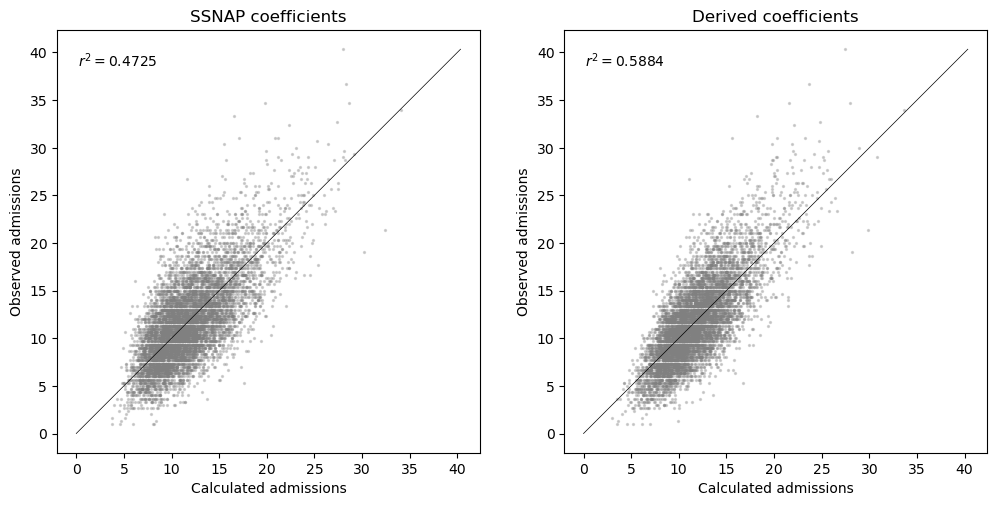

In [162]:
# fig, axs = plt.subplots(1, 4, figsize=(12, 4))
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Equal line:
for ax in axs[:2]:
    ax.plot([0, ad_max], [0, ad_max], color='k', linewidth=0.5)

# for q, q0 in enumerate(qmin_list):
#     mask = df_stats['depriv_quantile_min'] == q0
#     df_here = df_stats.filter(mask)
#     kwargs = dict(color=colours[q], s=2, alpha=1.0, label=legend_labels[q0])
#     axs[0].scatter(df_here['admissions'], df_here['admissions_predicted_ssnap'], **kwargs)
#     axs[1].scatter(df_here['admissions'], df_here['admissions_predicted_depriv'], **kwargs)
kwargs = dict(color='grey', s=2, alpha=0.3)
axs[0].scatter(df_stats['admissions_predicted_ssnap'], df_stats['admissions'], **kwargs)
axs[1].scatter(df_stats['admissions_predicted_depriv'], df_stats['admissions'], **kwargs)
   
for ax in axs[:2]:
    ax.set_ylabel('Observed admissions')
    ax.set_xlabel('Calculated admissions')
    ax.set_aspect('equal')

axs[0].set_title('SSNAP coefficients')
axs[1].set_title('Derived coefficients')

axs[0].annotate(r'$r^2=$' + f"{dict_r2_ssnap['r2_all']:.4f}", xy=(0.05, 0.95), ha='left', va='top', xycoords='axes fraction')
axs[1].annotate(r'$r^2=$' + f"{dict_r2['r2_all']:.4f}", xy=(0.05, 0.95), ha='left', va='top', xycoords='axes fraction')

plt.savefig('images/admissions_prediction_comparison.png', bbox_inches='tight')
plt.show()

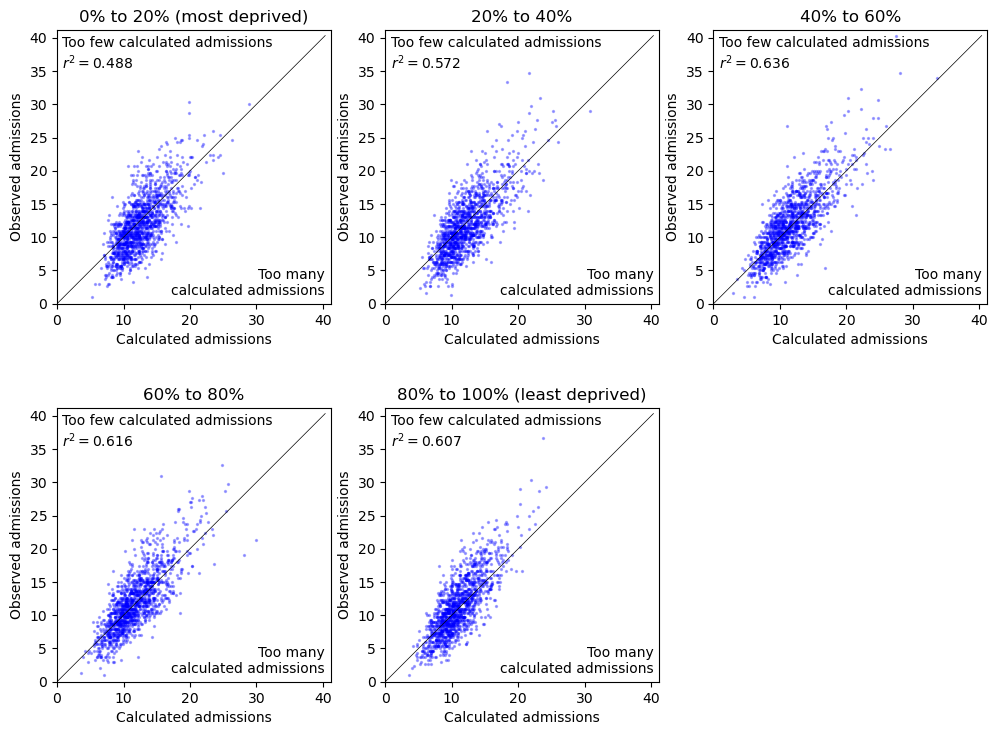

In [163]:
ncols=3
nrows=2
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 9))

for q, q0 in enumerate(qmin_list):
    ax = axs[q // ncols, q % ncols]
    # Equal line:
    ax.plot([0, ad_max], [0, ad_max], color='k', linewidth=0.5)

    mask = df_stats['depriv_quantile_min'] == q0
    df_here = df_stats.filter(mask)
    kwargs = dict(color=colours[q], s=2, alpha=1.0, label=legend_labels[q0])
    # ax.scatter(df_here['admissions'], df_here['admissions_predicted_ssnap'], **kwargs)
    ax.scatter(
        df_here['admissions_predicted_depriv'],
        df_here['admissions'],
        s=2,
        # color=colours[q],
        color='b',
        alpha=0.3
    )

    # Labels:
    ax.set_ylabel('Observed admissions')
    ax.set_xlabel('Calculated admissions')
    ax.set_title(legend_labels[q0])    
    # Annotate r-squared value:
    r2_key = f'r2_q{q0:.1f}'.replace('.', '')
    r_str = r'$r^2=$' + f"{dict_r2[r2_key]:.3f}"
    # ax.annotate(, xy=(0.05, 0.85), ha='left', va='top', xycoords='axes fraction')
    # Annotate which parts of the graph mean too high/low admissions:
    ax.annotate('Too few calculated admissions\n'+r_str, xy=(0.02, 0.98), ha='left', va='top', xycoords='axes fraction')
    ax.annotate('Too many\ncalculated admissions', xy=(0.98, 0.02), ha='right', va='bottom', xycoords='axes fraction')
    # Sizing:
    ax.set_ylim(0.0, zmax*1.02)
    ax.set_xlim(0.0, zmax*1.02)
    ax.set_aspect('equal')
    
axs[-1, -1].set_visible(False)

plt.savefig('images/admissions_prediction_comparison_separate.png', bbox_inches='tight')
plt.show()

In [164]:
dict_labels_1row = {}

for key, val in legend_labels.items():
    dict_labels_1row[key] = val.replace('(', '\n(')

In [165]:
import matplotlib.ticker  # for axis tick location

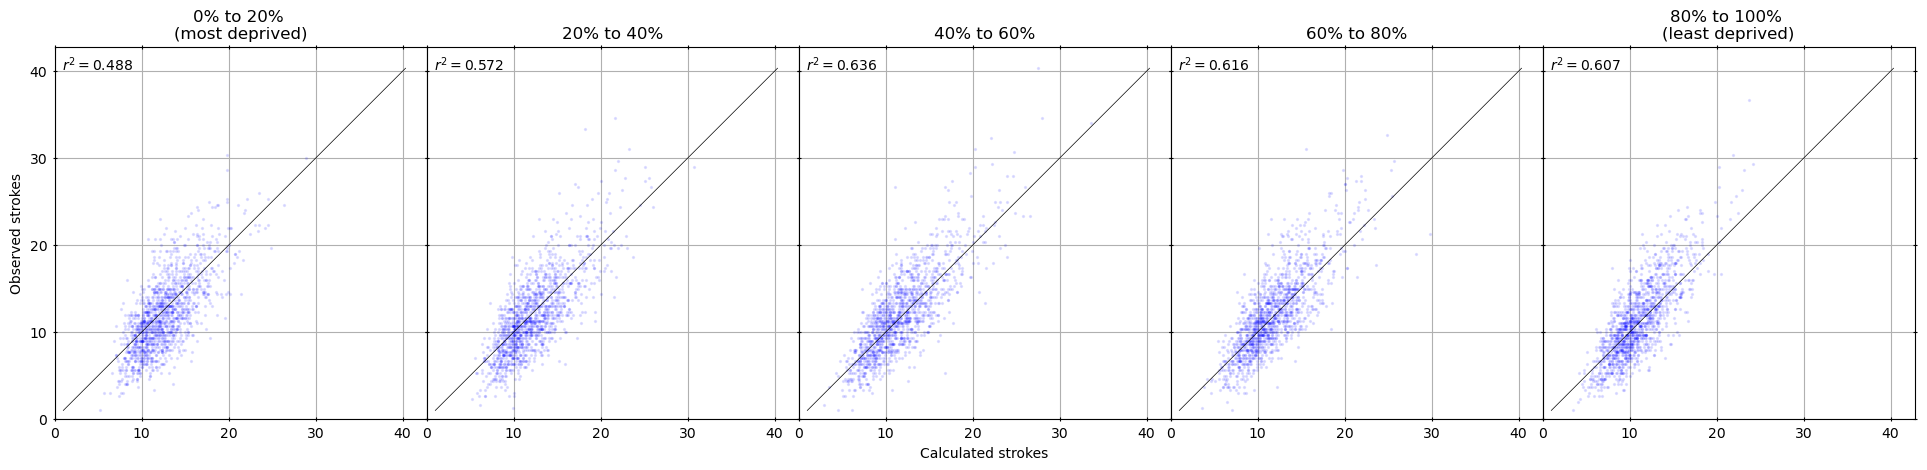

In [166]:
ncols=5
nrows=1
fig, axs = plt.subplots(nrows, ncols, figsize=(24, 10), sharey=True, sharex=True, gridspec_kw={'wspace': 0.0})

# Draw each quantile's data in turn:
for q, qmin in enumerate(qmin_list):
    ax = axs[q]# // ncols, q % ncols]
    # Equality line:
    ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5, zorder=6)
    
    df_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    ax.scatter(
        df_here['admissions_predicted_depriv'],
        df_here['admissions'],
        s=2,
        # color=colours[q],
        color='b',
        alpha=0.1,
        zorder=5
    )
    
    # Labels:
    if q == 0:
        ax.set_ylabel('Observed strokes')
    if q == 2:
        ax.set_xlabel('Calculated strokes')
    ax.set_title(dict_labels_1row[qmin])
    # Annotate r-squared value:
    r2_key = f'r2_q{qmin:.1f}'.replace('.', '')
    r_str = r'$r^2=$' + f"{dict_r2[r2_key]:.3f}"
    # ax.annotate(, xy=(0.05, 0.85), ha='left', va='top', xycoords='axes fraction')
    # Annotate which parts of the graph mean too high/low admissions:
    # ax.annotate('Too few calculated admissions\n'+r_str, xy=(0.02, 0.98), ha='left', va='top', xycoords='axes fraction')
    ax.annotate(r_str, xy=(0.02, 0.98), ha='left', va='top', xycoords='axes fraction')
    # ax.annotate('Too many\ncalculated admissions', xy=(0.98, 0.02), ha='right', va='bottom', xycoords='axes fraction')
    # Sizing:
    ax.set_xlim(0.0, zmax*1.06)
    ax.set_ylim(0.0, zmax*1.06)
    ax.set_aspect('equal')
    
    ax.tick_params(direction='inout', axis='both', top=True, right=True)
    ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(10))
    ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(10))
    ax.grid('on')

# Save:
plt.savefig('./images/admissions_prediction_comparison_separate_1row.png', bbox_inches='tight')
plt.show()

## Example population

Apply the different deprivation coefficients to the same population of people to see the effect it makes.

Use data for this MSOA in the middle deprivation quantile:

In [167]:
msoa_example = 'Adur 001'

df_example = df_stats.filter(df_stats['MSOA'] == msoa_example)

df_example[['admissions', 'depriv_quantile_min'] + age_numbers]

admissions,depriv_quantile_min,age_less65,age_65,age_70,age_75,age_over80
f64,f64,f64,f64,f64,f64,f64
14.333333,0.4,6939.168,492.7585,465.432,371.993,546.53


In [168]:
dict_example = {}

for q, qmin in enumerate(qmin_list):
    coeffs_example = coeffs_depriv.filter(np.round(coeffs_depriv['depriv_quantile_min'], 1) == np.round(qmin, 1))[cols_coeffs_depriv]
    
    admissions_example =  0.0
    for a in cols_coeffs_depriv:
        admissions_example += (coeffs_example[a].to_numpy()[0] * df_example[a]).to_numpy()[0]
    q_str = f'q{qmin:.1f}'.replace('.', '')
    dict_example[q_str] = round(admissions_example, 3)

In [169]:
dict_example

{'q00': 18.117, 'q02': 15.972, 'q04': 13.719, 'q06': 12.882, 'q08': 11.789}

Using the different deprivation quantiles can make a difference of a few admissions. This MSOA is in the middle quantile and its admissions can be overestimated by around 4 by using the most deprived quantile's coefficients or underestimated by around 2 by using the least deprived quantile's coefficients.